<a href="https://colab.research.google.com/github/eahernandezrangel-art/LabAvanzado/blob/main/Proyecto2_AnalisisdeFTIR_redesneauronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proyecto 2: Uso de redes neuronales para identificar que conjunto de variables obtenidas mediante analisis de bandas de FTIR discrimina mejor
 entre pacientes sanos y anemicos

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import levene
from sklearn.preprocessing import  StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline


In [47]:
#Cargamos las bases ,estas bases contiene el area de cada banda encontrada en el espectro del suero humano, el area de las subcompuestos proteicos
#de la banda amidaI obtenidas mediante una desconvolucion gaussiana y la combinacion de estas dos bases
areas=pd.read_excel('AreaFTIR_resumen.xlsx')
multigauss=pd.read_excel('multigauss_FTIR.xlsx')
total=pd.read_excel('Areas_con_multigauss_FTIR.xlsx')

#Vemos las dimensiones de la base
print(areas.shape)
print(multigauss.shape)
print(total.shape)

#veamos si los grupos estan balanceados
print("\nColumnas áreas:")
print(areas.columns)

print("\nGrupos en áreas:")
print(areas["Grupo"].value_counts())



(33, 11)
(33, 35)
(33, 44)

Columnas áreas:
Index(['Muestra', 'Grupo', 'Amida I', 'Amida II', 'Amida III',
       'C-H lípidos/proteínas', 'CH₂ / CH₃ deformación',
       'Fosfatos / C-O / carbohidratos', 'Huella digital baja', 'O-H / N-H',
       'Sobretonos / combinación'],
      dtype='object')

Grupos en áreas:
Grupo
anemico    18
asume       8
sano        7
Name: count, dtype: int64


In [3]:
# Ahora como en el anterior proyecto debemos primero realizar la mismas
#pruebas estadisticas , por lo que definimos una funcion general estadistica
#para aplicarla a cada base
def estadistica_ftir(df, nombre_base):

    variables = [
        col for col in df.columns
        if col not in ["Muestra", "Grupo"]
    ]

    resultados = []

    for var in variables:

        datos_sano = df[df["Grupo"] == "sano"][var].dropna()
        datos_anemia = df[df["Grupo"] == "anemico"][var].dropna()
        datos_asume = df[df["Grupo"] == "asume"][var].dropna()

        media_sano = datos_sano.mean()
        media_anemia = datos_anemia.mean()
        media_asume = datos_asume.mean()

        std_sano = datos_sano.std()
        std_anemia = datos_anemia.std()
        std_asume = datos_asume.std()

        try:
            U_sa, p_mw_sa = mannwhitneyu(
                datos_sano,
                datos_anemia,
                alternative="two-sided"
            )
        except:
            U_sa, p_mw_sa = np.nan, np.nan

        try:
            U_ss, p_mw_ss = mannwhitneyu(
                datos_sano,
                datos_asume,
                alternative="two-sided"
            )
        except:
            U_ss, p_mw_ss = np.nan, np.nan

        try:
            U_as, p_mw_as = mannwhitneyu(
                datos_anemia,
                datos_asume,
                alternative="two-sided"
            )
        except:
            U_as, p_mw_as = np.nan, np.nan

        try:
            t_sa, p_welch_sa = ttest_ind(
                datos_sano,
                datos_anemia,
                equal_var=False
            )
        except:
            t_sa, p_welch_sa = np.nan, np.nan

        try:
            t_ss, p_welch_ss = ttest_ind(
                datos_sano,
                datos_asume,
                equal_var=False
            )
        except:
            t_ss, p_welch_ss = np.nan, np.nan

        try:
            t_as, p_welch_as = ttest_ind(
                datos_anemia,
                datos_asume,
                equal_var=False
            )
        except:
            t_as, p_welch_as = np.nan, np.nan

        resultados.append({
            "Base": nombre_base,
            "Variable": var,

            "Media_Sano": media_sano,
            "STD_Sano": std_sano,

            "Media_Anemico": media_anemia,
            "STD_Anemico": std_anemia,

            "Media_Asume": media_asume,
            "STD_Asume": std_asume,

            "U_Sano_vs_Anemico": U_sa,
            "p_MW_Sano_vs_Anemico": p_mw_sa,

            "U_Sano_vs_Asume": U_ss,
            "p_MW_Sano_vs_Asume": p_mw_ss,

            "U_Anemico_vs_Asume": U_as,
            "p_MW_Anemico_vs_Asume": p_mw_as,

            "t_Sano_vs_Anemico": t_sa,
            "p_Welch_Sano_vs_Anemico": p_welch_sa,

            "t_Sano_vs_Asume": t_ss,
            "p_Welch_Sano_vs_Asume": p_welch_ss,

            "t_Anemico_vs_Asume": t_as,
            "p_Welch_Anemico_vs_Asume": p_welch_as
        })

    return pd.DataFrame(resultados)


In [5]:
# Aplicamos la función estadística a cada base

estad_areas = estadistica_ftir(
    areas,
    "Áreas FTIR"
)

estad_multigauss = estadistica_ftir(
    multigauss,
    "Multigauss"
)

estad_total = estadistica_ftir(
    total,
    "Combinada "
)

estad_todas = pd.concat(
    [
        estad_areas,
        estad_multigauss,
        estad_total
    ],
    ignore_index=True
)

estad_todas.round(4)

,Base,Variable,Media_Sano,STD_Sano,Media_Anemico,STD_Anemico,Media_Asume,STD_Asume,U_Sano_vs_Anemico,p_MW_Sano_vs_Anemico,U_Sano_vs_Asume,p_MW_Sano_vs_Asume,U_Anemico_vs_Asume,p_MW_Anemico_vs_Asume,t_Sano_vs_Anemico,p_Welch_Sano_vs_Anemico,t_Sano_vs_Asume,p_Welch_Sano_vs_Asume,t_Anemico_vs_Asume,p_Welch_Anemico_vs_Asume
0,Áreas FTIR,Amida I,7.0370,2.9512,3.5212,2.0274,3.9297,2.6063,108.0,0.0049,45.0,0.0541,67.0,0.8067,2.8973,0.0192,2.1477,0.0526,-0.3935,0.7015
1,Áreas FTIR,Amida II,5.0594,2.2676,2.5502,1.4466,2.7918,1.8518,107.0,0.0061,45.0,0.0541,73.0,0.9783,2.7203,0.0263,2.1025,0.0580,-0.3272,0.7497
2,Áreas FTIR,Amida III,1.2565,0.5610,0.6405,0.3490,0.7208,0.4535,107.0,0.0061,45.0,0.0541,74.0,0.9350,2.7086,0.0271,2.0154,0.0677,-0.4454,0.6648
3,Áreas FTIR,C-H lípidos/proteínas,1.6132,0.5993,1.0724,0.4683,1.3143,0.6857,97.0,0.0405,38.0,0.2810,60.0,0.5308,2.1460,0.0604,0.9007,0.3842,-0.9080,0.3852
4,Áreas FTIR,CH₂ / CH₃ deformación,0.6276,0.2874,0.3664,0.1636,0.4023,0.2642,102.0,0.0171,40.0,0.1893,77.0,0.8067,2.2662,0.0550,1.5724,0.1411,-0.3556,0.7299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Combinada,Beta/Total,0.5181,0.0107,0.5873,0.0290,0.5772,0.0260,0.0,0.0000,0.0,0.0003,86.0,0.4614,-8.7089,0.0000,-5.8864,0.0002,0.8791,0.3932
80,Combinada,Alpha/Total,0.2891,0.0130,0.2109,0.0513,0.2391,0.0239,125.0,0.0000,55.0,0.0006,52.0,0.2852,5.9874,0.0000,5.1125,0.0003,-1.9126,0.0679
81,Combinada,Turn/Total,0.1928,0.0067,0.2018,0.0353,0.1837,0.0283,69.0,0.7451,44.0,0.0721,110.0,0.0352,-1.0379,0.3118,0.8849,0.4024,1.3959,0.1810
82,Combinada,Alpha/Beta,0.5585,0.0353,0.3629,0.0983,0.4156,0.0505,126.0,0.0000,56.0,0.0003,47.0,0.1772,7.3171,0.0000,6.4145,0.0000,-1.8015,0.0846


In [7]:
#Veamos aquellas variabes que sean estadisticamentes significativas
def filtrar_significativas(tabla):

    return tabla[
        (tabla["p_MW_Sano_vs_Anemico"] < 0.05) &
        (tabla["p_Welch_Sano_vs_Anemico"] < 0.05)
    ].copy()


variables_sig_areas = filtrar_significativas(estad_areas)
variables_sig_multigauss = filtrar_significativas(estad_multigauss)
variables_sig_total = filtrar_significativas(estad_total)
variables_sig_todas = filtrar_significativas(estad_todas)

variables_sig_todas[
    [
        "Base",
        "Variable",
        "Media_Sano",
        "Media_Anemico",
        "Media_Asume",
        "p_MW_Sano_vs_Anemico",
        "p_Welch_Sano_vs_Anemico"
    ]
].sort_values(["Base", "p_MW_Sano_vs_Anemico"]).round(4)

,Base,Variable,Media_Sano,Media_Anemico,Media_Asume,p_MW_Sano_vs_Anemico,p_Welch_Sano_vs_Anemico
79,Combinada,Beta/Total,0.5181,0.5873,0.5772,0.0000,0.0000
82,Combinada,Alpha/Beta,0.5585,0.3629,0.4156,0.0000,0.0000
80,Combinada,Alpha/Total,0.2891,0.2109,0.2391,0.0000,0.0000
48,Combinada,Huella digital baja,11.9082,2.1217,1.3305,0.0001,0.0012
59,Combinada,Mu_β-sheet_1638,1635.7437,1638.4294,1638.3163,0.0002,0.0000
61,Combinada,Area_α-helix_1650,1.2524,0.4195,0.5539,0.0002,0.0109
62,Combinada,Mu_α-helix_1650,1648.0001,1649.5126,1649.0027,0.0002,0.0000
63,Combinada,Sigma_α-helix_1650,7.4270,5.8283,6.2249,0.0002,0.0000
56,Combinada,Mu_β-sheet_1628,1623.3112,1625.6608,1625.2427,0.0003,0.0000
70,Combinada,Area_β-turn_1681,0.4822,0.2050,0.2525,0.0004,0.0058


In [12]:
#Con lo anterior  podemos observar que algunas bases de datos contienen un numero
#comparable  o incluso superior al número de muestras disponibles, por lo que se
# empleara un Analisis de Componentes Principales para reducir dimensionalidad y explorar la estructura
# de los datos y ver que variables verdaderamente describen a las muestras

#Como tenemos 3 bases de datos nos conviene crear una funcion general para el PCA, por lo qu
def hacer_pca(df, nombre_base):

    # Separar variables y grupos
    X = df.drop(columns=["Muestra", "Grupo"])
    y = df["Grupo"]

    # Escalar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Varianza explicada
    print(f"\n===== {nombre_base} =====")
    print("Variables:", X.shape[1])

    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"PC{i+1}: {var:.4f}")

    # Gráfica varianza acumulada
    plt.figure(figsize=(7,4))

    plt.plot(
        np.arange(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_),
        "o-"
    )

    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza acumulada")
    plt.title(f"PCA - {nombre_base}")
    plt.grid()
    plt.show()

    # Gráfica PC1 vs PC2
    plt.figure(figsize=(7,6))

    for grupo in y.unique():
        mask = y == grupo

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            s=80,
            label=grupo
        )

    plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
    plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
    plt.title(f"PCA - {nombre_base}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    #Cargas del PCA, es decir que componente nos da mas informacion
    cargas=pd.DataFrame(
        pca.components_.T,
        index=X.columns,
        columns=[f"PC{i+1}" for i in range(len(pca.components_))]
    )

    return X, y, X_scaled, pca, X_pca, cargas


===== Areas de FTIR =====
Variables: 9
PC1: 0.8735
PC2: 0.0807
PC3: 0.0290
PC4: 0.0074
PC5: 0.0053
PC6: 0.0020
PC7: 0.0014
PC8: 0.0005
PC9: 0.0001


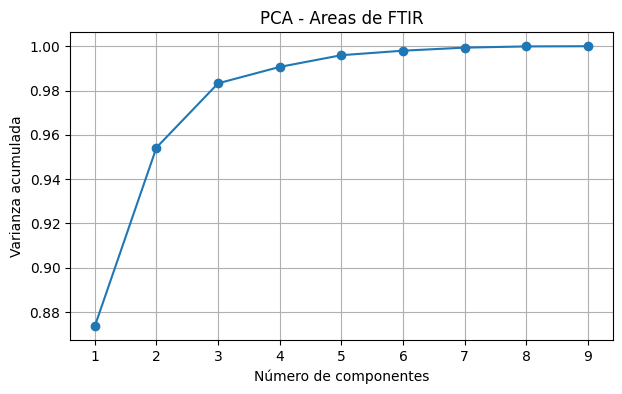

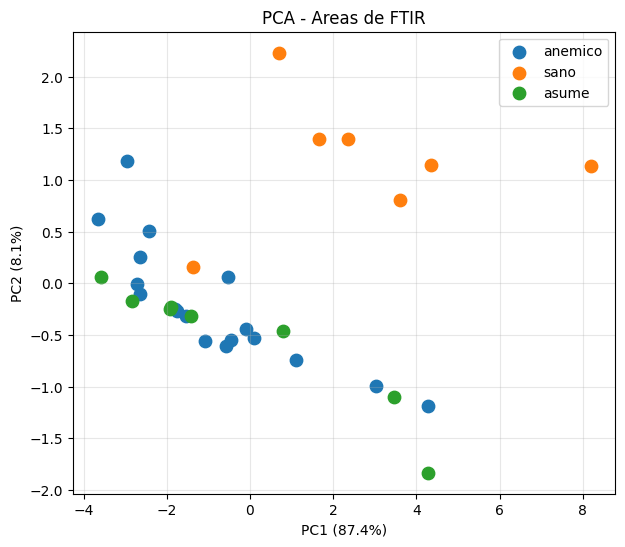


===== Multigauss =====
Variables: 33
PC1: 0.4353
PC2: 0.1675
PC3: 0.1521
PC4: 0.0606
PC5: 0.0516
PC6: 0.0423
PC7: 0.0305
PC8: 0.0156
PC9: 0.0130
PC10: 0.0087
PC11: 0.0061
PC12: 0.0053
PC13: 0.0038
PC14: 0.0023
PC15: 0.0016
PC16: 0.0012
PC17: 0.0011
PC18: 0.0005
PC19: 0.0004
PC20: 0.0002
PC21: 0.0002
PC22: 0.0001
PC23: 0.0000
PC24: 0.0000
PC25: 0.0000
PC26: 0.0000
PC27: 0.0000
PC28: 0.0000
PC29: 0.0000
PC30: 0.0000
PC31: 0.0000
PC32: 0.0000
PC33: 0.0000


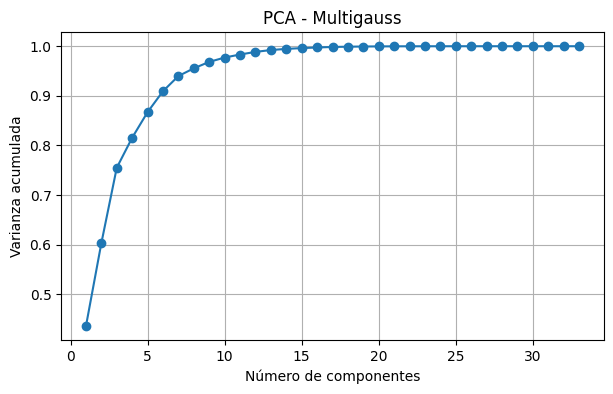

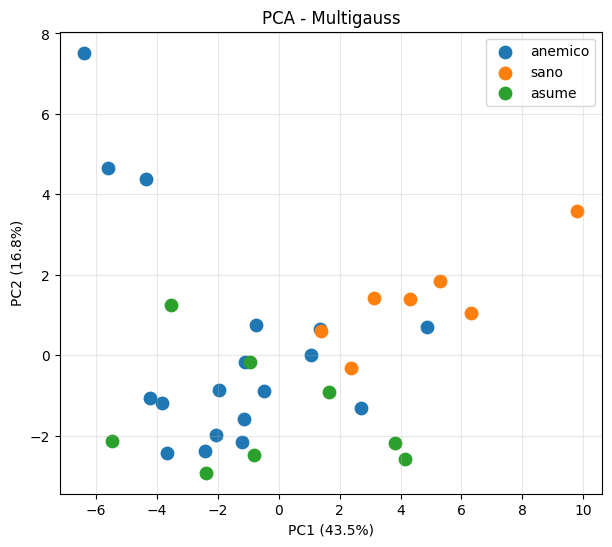


===== Total =====
Variables: 42
PC1: 0.5077
PC2: 0.1461
PC3: 0.1326
PC4: 0.0489
PC5: 0.0413
PC6: 0.0366
PC7: 0.0241
PC8: 0.0133
PC9: 0.0105
PC10: 0.0098
PC11: 0.0066
PC12: 0.0054
PC13: 0.0041
PC14: 0.0030
PC15: 0.0027
PC16: 0.0020
PC17: 0.0013
PC18: 0.0012
PC19: 0.0008
PC20: 0.0006
PC21: 0.0004
PC22: 0.0003
PC23: 0.0002
PC24: 0.0001
PC25: 0.0001
PC26: 0.0001
PC27: 0.0000
PC28: 0.0000
PC29: 0.0000
PC30: 0.0000
PC31: 0.0000
PC32: 0.0000
PC33: 0.0000


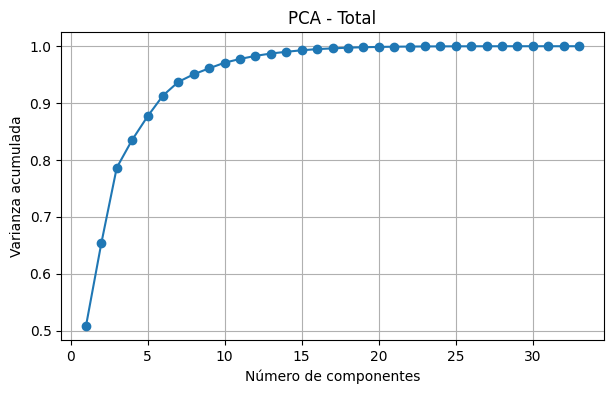

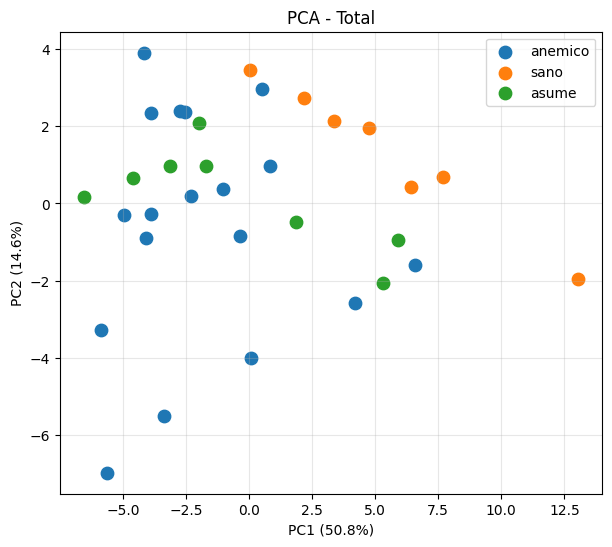

In [13]:
#Teniendo el general ,ahora podemos definir para cada base

#PCA solo para areas de FTIR
X_areas, y_areas, X_scaled_areas, pca_areas, X_pca_areas, cargas_areas = hacer_pca(areas, "Areas de FTIR")
#PCA para multigauss
X_multigauss, y_multigauss, X_scaled_multigauss, pca_multigauss, X_pca_multigauss, cargas_multigauss = hacer_pca(multigauss, "Multigauss")
#PCA combinado
X_total, y_total, X_scaled_total, pca_total, X_pca_total, cargas_total = hacer_pca(total, "Total")

In [16]:
# Función para identificar las variables con mayor contribución a cada componente principal

def top_cargas(cargas, pc="PC1", n=10):

    tabla = cargas[[pc]].copy()
    tabla["abs_carga"] = tabla[pc].abs()

    return tabla.sort_values(
        "abs_carga",
        ascending=False
    ).head(n)

In [17]:
# Variables que más contribuyen a PC1, PC2 y PC3 en áreas FTIR

print("Áreas FTIR - PC1")
display(top_cargas(cargas_areas, "PC1", 10))

print("Áreas FTIR - PC2")
display(top_cargas(cargas_areas, "PC2", 10))

print("Áreas FTIR - PC3")
display(top_cargas(cargas_areas, "PC3", 10))

Áreas FTIR - PC1


,PC1,abs_carga
Amida I,0.353503,0.353503
Amida II,0.353184,0.353184
Amida III,0.352718,0.352718
O-H / N-H,0.348374,0.348374
Sobretonos / combinación,0.346657,0.346657
CH₂ / CH₃ deformación,0.345371,0.345371
C-H lípidos/proteínas,0.342451,0.342451
Fosfatos / C-O / carbohidratos,0.317076,0.317076
Huella digital baja,0.217392,0.217392


Áreas FTIR - PC2


,PC2,abs_carga
Huella digital baja,0.919866,0.919866
Fosfatos / C-O / carbohidratos,-0.278969,0.278969
C-H lípidos/proteínas,-0.237646,0.237646
O-H / N-H,-0.090510,0.090510
CH₂ / CH₃ deformación,-0.087208,0.087208
Sobretonos / combinación,0.055204,0.055204
Amida I,0.020457,0.020457
Amida II,0.016696,0.016696
Amida III,-0.002127,0.002127


Áreas FTIR - PC3


,PC3,abs_carga
Fosfatos / C-O / carbohidratos,0.743731,0.743731
CH₂ / CH₃ deformación,0.387172,0.387172
O-H / N-H,-0.299523,0.299523
Huella digital baja,0.209208,0.209208
Amida I,-0.201995,0.201995
Amida II,-0.201468,0.201468
Sobretonos / combinación,-0.200828,0.200828
C-H lípidos/proteínas,-0.168423,0.168423
Amida III,-0.115718,0.115718


In [ ]:
#Vemos que el primer componente explica aproximadamente un 80%e la varianza
#total y presentó contribuciones similares de todas las regiones espectrales consideradas.
# Esto indica que la principal fuente de variacion entre muestras corresponde a cambios
#globales en la intensidad de absorcion de las bandas FTIR asociadas a proteinas,
#lipidos y carbohidratos sericos.El segundo componente principal explico un 8.1% adicional
#de la varianza y estuvo dominado principalmente por las regiones asociadas  la huella digital baja,
#esta region es muy interesante porque esta asociada a compuestos ligados a la absorcion de medicamentos,
#Un hecho imporatante al ser pacientes anemico de piso es decir que puede o no esten en tratamiento, mientras
# que el tercer componente esta dominado  por enlaces C-O .


In [18]:
# Variables que más contribuyen a PC1, PC2 y PC3 en multigausss

print("Multigauss - PC1")
display(top_cargas(cargas_multigauss, "PC1", 10))

print("Multigauss - PC2")
display(top_cargas(cargas_multigauss, "PC2", 10))

print("Multigauss - PC3")
display(top_cargas(cargas_multigauss, "PC3", 10))

Multigauss - PC1


,PC1,abs_carga
Area_α-helix_1657,0.253322,0.253322
Area_alpha_total,0.252062,0.252062
Area_β-turn_1681,0.250952,0.250952
Area_α-helix_1650,0.244769,0.244769
Area_total_gauss,0.239566,0.239566
Area_β-sheet intermolecular_1618,0.236502,0.236502
Area_beta_total,0.229243,0.229243
Area_turn_total,0.225392,0.225392
Area_β-sheet_1638,0.217794,0.217794
Alpha/Beta,0.206551,0.206551


Multigauss - PC2


,PC2,abs_carga
Sigma_β-turn_1673,0.364394,0.364394
Turn/Beta,0.362801,0.362801
Turn/Total,0.358451,0.358451
Mu_β-turn_1673,-0.356442,0.356442
Sigma_α-helix_1657,-0.256679,0.256679
Mu_β-sheet_1628,-0.223221,0.223221
Area_β-turn_1673,0.211144,0.211144
Sigma_β-sheet_1628,-0.206289,0.206289
Alpha/Total,-0.173329,0.173329
Mu_β-sheet_1691,0.166524,0.166524


Multigauss - PC3


,PC3,abs_carga
Area_β-sheet_1691,0.333052,0.333052
Area_β-sheet_1628,0.330492,0.330492
Mu_β-sheet_1638,0.303574,0.303574
Sigma_β-sheet_1628,0.266643,0.266643
Beta/Total,0.256602,0.256602
Mu_α-helix_1650,0.252722,0.252722
Mu_β-sheet_1628,0.237925,0.237925
Sigma_α-helix_1650,-0.235226,0.235226
Alpha/Beta,-0.203417,0.203417
Area_beta_total,0.200557,0.200557


In [ ]:
# Aqui ya vemos algo mucho mas interesante a nivel estructural,el primer componente
# esta dominado por informacion  asociada al contenido global de alpha helice, mientras
# que el segundo componente estuvo fuertemente influenciado por parametros relacionados
#con estructuras beta turn y sus proporciones relativas. El tercer componente se puede
#asociar a las estructuras beta plegables .Esto ya nos sugiere  que la principal fuente de variabilidad
#entre las muestras estan asociado tanto a cambios globales en la estructura secundaria proteica,
# como a modificaciones especificas  en la contribucion de giros beta.

In [19]:
# Variables que más contribuyen a PC1, PC2 y PC3 en combinado

print("Total - PC1")
display(top_cargas(cargas_total, "PC1", 10))

print("Total - PC2")
display(top_cargas(cargas_total, "PC2", 10))

print("Total - PC3")
display(top_cargas(cargas_total, "PC3", 10))

Total - PC1


,PC1,abs_carga
Area_alpha_total,0.213558,0.213558
Area_α-helix_1657,0.213118,0.213118
Area_β-turn_1681,0.211761,0.211761
Amida I,0.210466,0.210466
Area_total_gauss,0.210406,0.210406
Area_α-helix_1650,0.208454,0.208454
Amida II,0.207895,0.207895
Area_β-sheet intermolecular_1618,0.207041,0.207041
Sobretonos / combinación,0.206402,0.206402
Amida III,0.205787,0.205787


Total - PC2


,PC2,abs_carga
Sigma_α-helix_1657,0.290420,0.290420
Alpha/Total,0.278903,0.278903
Alpha/Beta,0.262600,0.262600
Mu_α-helix_1650,-0.260869,0.260869
Mu_β-turn_1673,0.240245,0.240245
Sigma_α-helix_1650,0.230221,0.230221
Sigma_β-turn_1673,-0.229928,0.229928
Sigma_β-turn_1681,0.229305,0.229305
Beta/Total,-0.208417,0.208417
Turn/Total,-0.208292,0.208292


Total - PC3


,PC3,abs_carga
Turn/Beta,0.367058,0.367058
Sigma_β-sheet_1628,-0.315156,0.315156
Mu_β-sheet_1628,-0.307859,0.307859
Turn/Total,0.302994,0.302994
Sigma_β-turn_1673,0.289144,0.289144
Mu_β-turn_1673,-0.272896,0.272896
Mu_β-sheet_1638,-0.253577,0.253577
Area_β-sheet_1628,-0.239903,0.239903
Sigma_β-sheet_1638,0.212374,0.212374
Area_β-sheet_1691,-0.189599,0.189599


In [ ]:
#Aqui obsevamos algo tambien interesante, en este caso dominan 3 componentes, donde
#el primer componente podemos asociarlo con las areas de las bandas de AmidaI,II yIII ,
# asi como el contenido total de alpha helice y el area total de descovolucion gaussiana.
#El segundo componente esta dominado por relaciones estructurales como lo es Alpha/total
#Alpha/Beta y Beta/Total, indicando que este eje describe cambios relativos entre alpha helice
# y beta plegable. Finalmete el tercer componente  nos habla de la relacionado con los giros,
# ademas del desplazamiento y anchuras corresondientes por picos.Es decir nos esta dando una
# vision mas global de los cambios estructurales relacionando directamente los picos proteicos
#principales que son los amida con el cambio subestructural que e presenta por muestra incluyendo
# relacionando cambios en el desplazamiento y anchura de banda.

In [22]:
#Ahora definimos iuna funcion para grficar cualquier combinacion de componentes principales, ppara
#observar mas a detalle la combinacion con PC3 que tiene informacion interesante
# Función para graficar cualquier combinación de componentes principales
def graficar_pcs(X_pca, pca, y, nombre_base, pcx=1, pcy=3):

    idx_x = pcx - 1
    idx_y = pcy - 1

    plt.figure(figsize=(7, 6))

    for grupo in y.unique():
        mask = y == grupo

        plt.scatter(
            X_pca[mask, idx_x],
            X_pca[mask, idx_y],
            s=80,
            label=grupo
        )

    plt.axhline(0, color="gray", linewidth=1, linestyle="--")
    plt.axvline(0, color="gray", linewidth=1, linestyle="--")

    plt.xlabel(f"PC{pcx} ({100*pca.explained_variance_ratio_[idx_x]:.1f}%)")
    plt.ylabel(f"PC{pcy} ({100*pca.explained_variance_ratio_[idx_y]:.1f}%)")
    plt.title(f"PCA - {nombre_base}: PC{pcx} vs PC{pcy}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

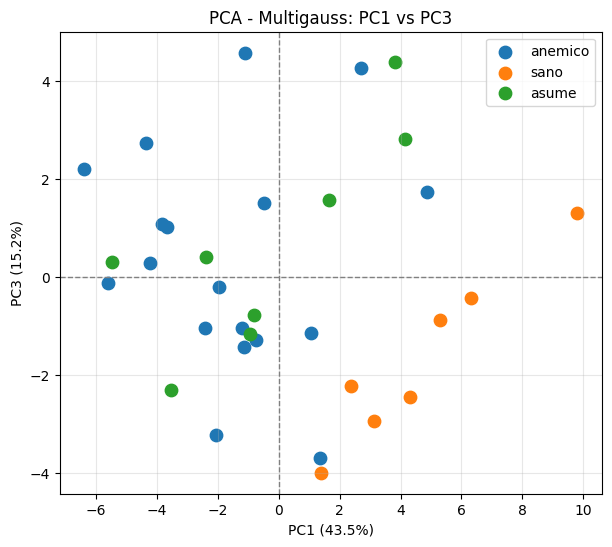

In [23]:
#Veamos para multigauss
graficar_pcs(
    X_pca_multigauss,
    pca_multigauss,
    y_multigauss,
    "Multigauss",
    pcx=1,
    pcy=3
)

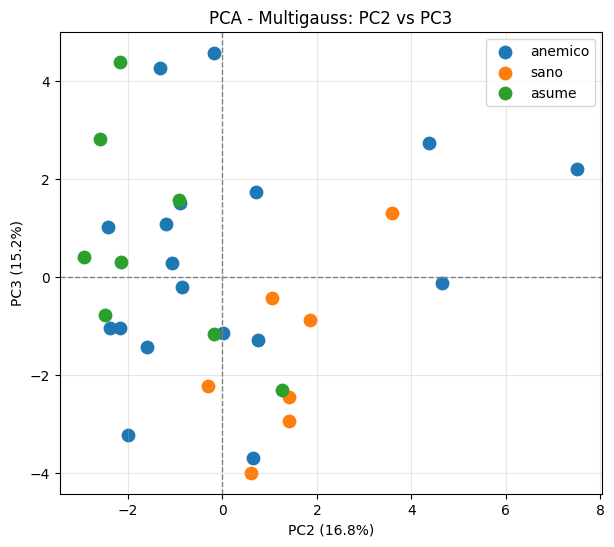

In [24]:
graficar_pcs(
    X_pca_multigauss,
    pca_multigauss,
    y_multigauss,
    "Multigauss",
    pcx=2,
    pcy=3
)

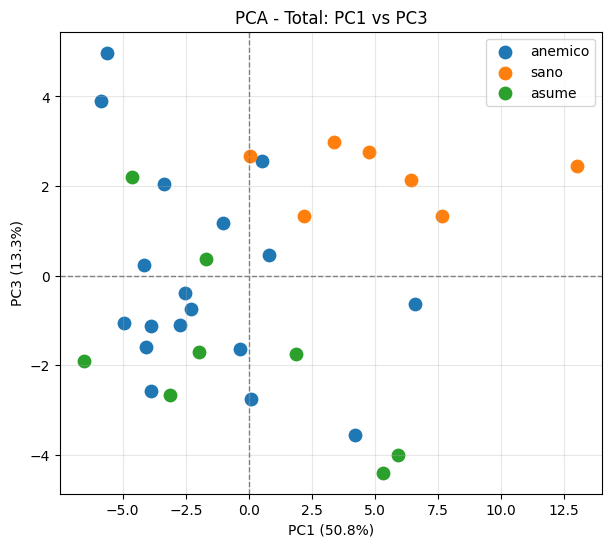

In [25]:
#Veamos para combinacion
graficar_pcs(
    X_pca_total,
    pca_total,
    y_total,
    "Total",
    pcx=1,
    pcy=3
)

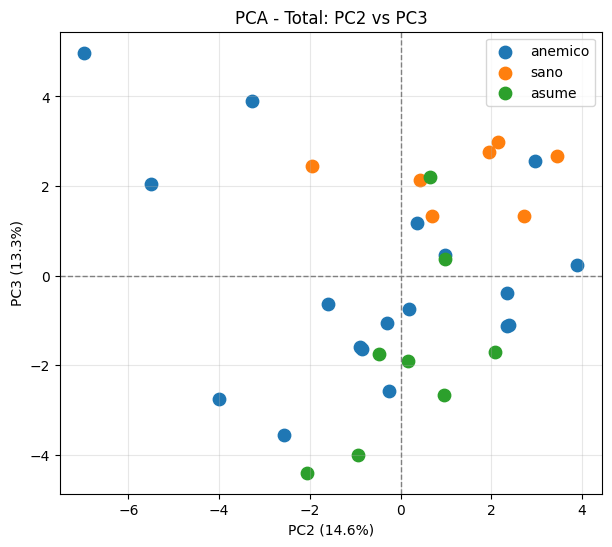

In [26]:
graficar_pcs(
    X_pca_total,
    pca_total,
    y_total,
    "Total",
    pcx=2,
    pcy=3
)

In [14]:
#Hagamos una tabla de varianza acumulada
def resumen_varianza(pca, nombre_base):
    var_acum = np.cumsum(pca.explained_variance_ratio_)

    return pd.DataFrame({
        'Base': nombre_base,
        'PC': np.arange(1, len(var_acum) + 1),
        'Varianza explicada': pca.explained_variance_ratio_,
        'Varianza acumulada': var_acum
    })

tabla_varianza = pd.concat([
    resumen_varianza(pca_areas, "Áreas FTIR"),
    resumen_varianza(pca_multigauss, "Multigauss"),
    resumen_varianza(pca_total, "Combinada")
])

tabla_varianza.head(20)


,Base,PC,Varianza explicada,Varianza acumulada
0,Áreas FTIR,1,0.873537,0.873537
1,Áreas FTIR,2,0.080694,0.954231
2,Áreas FTIR,3,0.029015,0.983246
3,Áreas FTIR,4,0.007412,0.990658
4,Áreas FTIR,5,0.005290,0.995948
5,Áreas FTIR,6,0.002038,0.997985
6,Áreas FTIR,7,0.001377,0.999362
7,Áreas FTIR,8,0.000548,0.999910
8,Áreas FTIR,9,0.000090,1.000000
0,Multigauss,1,0.435288,0.435288


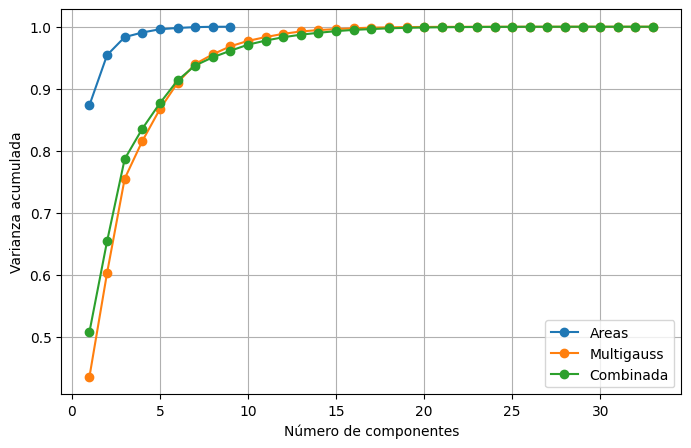

In [20]:
#Veamos una comparativa en grafica
plt.figure(figsize=(8,5))

for nombre, pca in [
    ("Areas", pca_areas),
    ("Multigauss", pca_multigauss),
    ("Combinada", pca_total)
]:

    plt.plot(
        np.arange(
            1,
            len(pca.explained_variance_ratio_)+1
        ),
        np.cumsum(
            pca.explained_variance_ratio_
        ),
        "o-",
        label=nombre
    )

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.legend()
plt.grid()
plt.show()

In [51]:
# Con la grafica podemos observas que para alcanzar una varianza acumulada del 90% ocupamos
# para areas 2 componentes, multigauss 6 componentes y combinada aproximadamente entre 5 o 6 componentes.
#ahora hagamos una analisis no supervisado para ver sin decirle al algoritmo quien es quien,
#vemos si los datos forman 3 grupos parecidos a las etiquetas reales, para ello construimos u kmean

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import confusion_matrix

#Definimos la funcion general Kmeans usando PCA, usaremos los primero componente
def hacer_kmeans_pca(X_pca, y, pca, nombre_base, n_componentes=2, k=3):

    # Tomamos solo las primeras componentes
    X_red = X_pca[:, :n_componentes]

    # Aplicamos K-means
    kmeans = KMeans(
        n_clusters=k,
        random_state=1,
        n_init=20
    )

    clusters = kmeans.fit_predict(X_red)

    # Métricas exploratorias
    ari = adjusted_rand_score(y, clusters)
    sil = silhouette_score(X_red, clusters)

    print(f"\n===== K-means: {nombre_base} =====")
    print("Número de componentes usadas:", n_componentes)
    print("Número de clusters:", k)
    print("Adjusted Rand Index:", ari)
    print("Silhouette score:", sil)

    # Tabla grupo real vs cluster
    tabla_clusters = pd.crosstab(
        y,
        clusters,
        rownames=["Grupo real"],
        colnames=["Cluster"]
    )

    display(tabla_clusters)

    # Gráfica usando PC1 y PC2
    plt.figure(figsize=(7, 6))

    for cluster in np.unique(clusters):
        mask = clusters == cluster

        plt.scatter(
            X_red[mask, 0],
            X_red[mask, 1],
            s=80,
            label=f"Cluster {cluster}"
        )

    plt.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        s=200,
        marker="X",
        color="black",
        label="Centroides"
    )

    plt.axhline(0, color="gray", linewidth=1, linestyle="--")
    plt.axvline(0, color="gray", linewidth=1, linestyle="--")

    plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
    plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
    plt.title(f"K-means sobre PCA - {nombre_base}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return clusters, kmeans, ari, sil, tabla_clusters





===== K-means: Áreas FTIR =====
Número de componentes usadas: 2
Número de clusters: 3
Adjusted Rand Index: 0.05568917668825162
Silhouette score: 0.47624861351681935


Cluster,0,1,2
Grupo real,,,
anemico,10,2,6
asume,5,2,1
sano,1,3,3


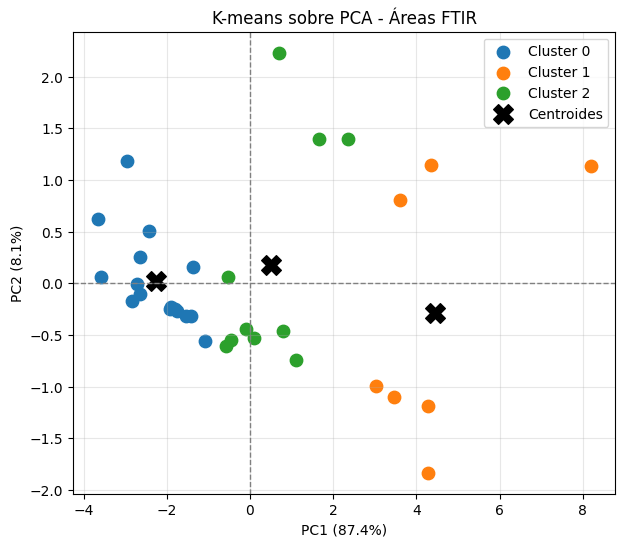

In [52]:
#aplicamos el kmeans a areas de FTIR
clusters_areas, kmeans_areas, ari_areas, sil_areas, tabla_clusters_areas = hacer_kmeans_pca(
    X_pca_areas,
    y_areas,
    pca_areas,
    "Áreas FTIR",
    n_componentes=2,
    k=3
)


In [ ]:
#Aqui no hay una separacion perfecta, pero el siluette nos marca un valor
#moderado al encontrarse en aprox 0.48,miwntra que ari nos indica un
#vaolor de 0.056 un valor bajo que significa que esos clusters no
#coinciden muy bien con las etiquetas clínicas reales. Pero aun asi se ve
# algo: el cluster 0 está dominado por anemicos y asume, mientras que los
# sanos se reparten mas entre cluster 1 y 2. Esto coincide con el PCA: el
#grupo sano se va hacia la derecha, pero los asume se mezclan mas con anemico


===== K-means: Multigauss =====
Número de componentes usadas: 3
Número de clusters: 3
Adjusted Rand Index: 0.12787554808096582
Silhouette score: 0.3957868380020929


Cluster,0,1,2
Grupo real,,,
anemico,4,3,11
asume,3,0,5
sano,7,0,0


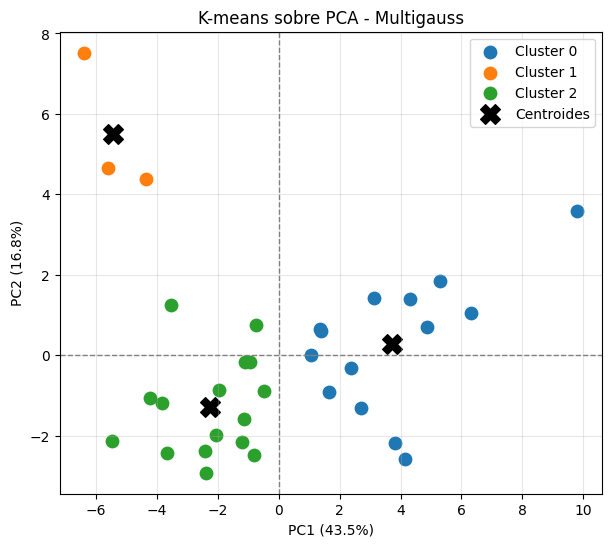

In [32]:
#Aplicamos a multigauss aqui conviente tomar 3 componentes por la cantidad de informacion que da
#PC3

clusters_multigauss, kmeans_multigauss, ari_multigauss, sil_multigauss, tabla_clusters_multigauss = hacer_kmeans_pca(
    X_pca_multigauss,
    y_multigauss,
    pca_multigauss,
    "Multigauss",
    n_componentes=3,
    k=3
)

In [ ]:
#El silhouette es de aprox 0.40 no esta mal indica que geométricamente sí
# hay cierta formación de clusters en el espacio PCA.Pero el ari de 0.13
#bajo nos hablade que las etiquetas no coinciden con las clinicas , el
# cluster 0 contiene todos los sanos, pero también anémicos y asume.
#El cluster 1 contiene solo 3 anémicos, parece un subgrupo extremo.
#El cluster 2 está dominado por anémicos y asume.


===== K-means: Combinada =====
Número de componentes usadas: 3
Número de clusters: 3
Adjusted Rand Index: 0.17507330509729585
Silhouette score: 0.4141558809395773


Cluster,0,1,2
Grupo real,,,
anemico,13,2,3
asume,5,3,0
sano,1,6,0


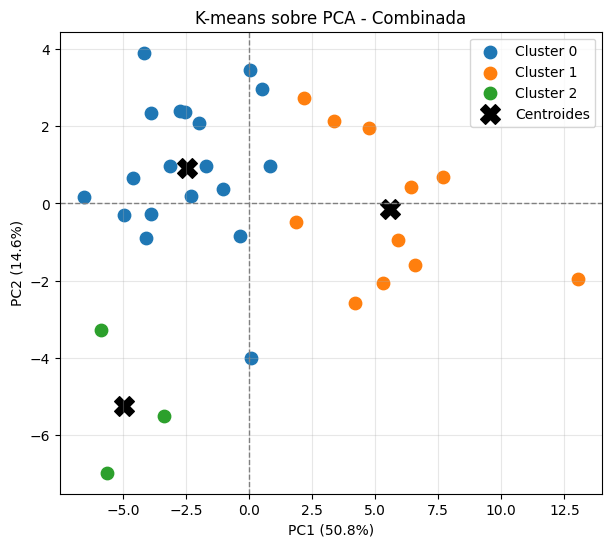

In [33]:
#Aplicamos a combinada
clusters_total, kmeans_total, ari_total, sil_total, tabla_clusters_total = hacer_kmeans_pca(
    X_pca_total,
    y_total,
    pca_total,
    "Combinada",
    n_componentes=3,
    k=3
)

In [ ]:
#igual que los anteriores  mantiene un ari bajo y un silhouette media
#el cluster 0 en este caso se encuentra dominado por anemicos y asume,
#cluster 1 la mayoria son sanos y el cluster 2 contiene solo anemicos,
#posiblemente muestras mas extremas.

In [34]:
#Comparamos resultados del kmeans
resultados_kmeans = pd.DataFrame({
    "Base": [
        "Áreas FTIR",
        "Multigauss",
        "Combinada"
    ],
    "Componentes PCA usadas": [
        2,
        3,
        3
    ],
    "k": [
        3,
        3,
        3
    ],
    "Adjusted Rand Index": [
        ari_areas,
        ari_multigauss,
        ari_total
    ],
    "Silhouette score": [
        sil_areas,
        sil_multigauss,
        sil_total
    ]
})

resultados_kmeans.round(4)

,Base,Componentes PCA usadas,k,Adjusted Rand Index,Silhouette score
0,Áreas FTIR,2,3,0.0557,0.4762
1,Multigauss,3,3,0.1279,0.3958
2,Combinada,3,3,0.1751,0.4142


In [54]:
#Obsevamos que el analisis no supervisado en todas la bases arrrojo un silhoutte moderad
#y un ari bajo.
# Ahora que reducimos variables y  probamos con un analisis no supervisado
#podemos pasar a probar un entreneamiento supervisado

# codificamos etiquetas
encoder = LabelEncoder()
encoder.fit(areas["Grupo"])

print("Clases:", encoder.classes_)

Clases: ['anemico' 'asume' 'sano']


In [55]:
#Ahora como tenemos 33 muestras no nos conviene hacer una separacion con
# train_test_split porque perderiamos demasiadas muestras, entonces optamos
# por hacer validacion cruzada.
# Ademas usamos Pipeline para que el escalado y el PCA se hagan dentro de cada
# fold y asi evitar que el PCA vea todos los datos antes de entrenar.

def evaluar_modelo_pipeline(df, nombre_base, n_components, arquitectura=(10,), n_splits=3):

    #Separamos las variables y los grupos
    X = df.drop(columns=["Muestra", "Grupo"])
    y = encoder.transform(df["Grupo"])

    # Definimos la red neuronal, iniciamos por una sencilla.
    # El pipeline primero escala los datos, luego aplica PCA y finalmente
    # entrena la red neuronal MLP.
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=arquitectura,
            activation="relu",
            solver="adam",
            max_iter=5000,
            random_state=1
        ))
    ])

    # Hacemos validación cruzada.
    # Aqui la funcion StratifiedKFold divide las 33 muestras en el numero de
    # divisiones que le indiquemos. En este caso usamos 3 folds porque tenemos
    # pocas muestras y los grupos estan desbalanceados.

    # Con 3 folds, el modelo entrena con aproximadamente 22 muestras y prueba
    # con aproximadamente 11 muestras. Despues cambia las muestras de prueba
    # y repite el proceso, de forma que todas las muestras se usan para prueba
    # alguna vez.

    # Ademas, al ser estratificada, intenta conservar la proporcion de grupos
    # sano, anemico y asume en cada fold.
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=1
    )

    # cross_val_score entrena y evalua el modelo en cada fold.
    # La metrica que usamos es accuracy.
    scores = cross_val_score(
        modelo,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(f"\n===== {nombre_base} =====")
    print("Componentes PCA:", n_components)
    print("Arquitectura:", arquitectura)
    print("Accuracy por fold:", scores)
    print("Accuracy promedio:", scores.mean())
    print("Desviación estándar:", scores.std())

    return scores.mean(), scores.std(), scores, modelo, cv

In [57]:
#Ahora definimos para Areas de FTIR
acc_areas, std_areas, scores_areas, modelo_areas, cv_areas = evaluar_modelo_pipeline(
    areas,
    "Áreas FTIR",
    n_components=2,
    arquitectura=(10,),
    n_splits=3
)



===== Áreas FTIR =====
Componentes PCA: 2
Arquitectura: (10,)
Accuracy por fold: [0.54545455 0.72727273 0.72727273]
Accuracy promedio: 0.6666666666666666
Desviación estándar: 0.08570991287109671


In [59]:
# Seguimos Multigauss
acc_multigauss, std_multigauss, scores_multigauss, modelo_multigauss, cv_multigauss = evaluar_modelo_pipeline(
    multigauss,
    "Multigauss",
    n_components=6,
    arquitectura=(10,),
    n_splits=3)


===== Multigauss =====
Componentes PCA: 6
Arquitectura: (10,)
Accuracy por fold: [0.36363636 0.72727273 0.72727273]
Accuracy promedio: 0.6060606060606061
Desviación estándar: 0.17141982574219336


In [60]:
#Finalmente la combinada
acc_total, std_total, scores_total, modelo_total, cv_total = evaluar_modelo_pipeline(
    total,
    "Combinada",
    n_components=6,
    arquitectura=(10,),
    n_splits=3)


===== Combinada =====
Componentes PCA: 6
Arquitectura: (10,)
Accuracy por fold: [0.36363636 0.72727273 0.63636364]
Accuracy promedio: 0.5757575757575757
Desviación estándar: 0.15451574283614497


In [61]:
#Armamos una tabla que nos resuma
resultados = pd.DataFrame({
    'Base': ['Areas FTIR', 'Multigauss', 'Combinada'],
    'Accuracy promedio': [acc_areas, acc_multigauss, acc_total],
    'Desviación estándar': [std_areas, std_multigauss, std_total]
})

resultados

,Base,Accuracy promedio,Desviación estándar
0,Areas FTIR,0.666667,0.085710
1,Multigauss,0.606061,0.171420
2,Combinada,0.575758,0.154516


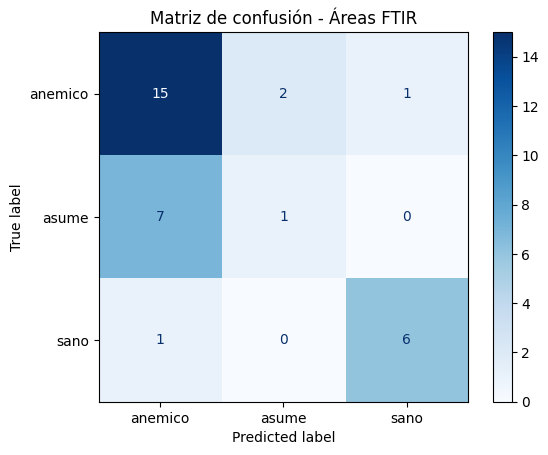

In [64]:
# Graficamos la matriz de confusión usando la mejor base: Áreas FTIR

# Primero definimos X e y de la base original.
# No usamos X_areas_red porque el Pipeline ya hace el escalado y el PCA dentro de cada fold.
X_areas_modelo = areas.drop(columns=["Muestra", "Grupo"])
y_areas_num = encoder.transform(areas["Grupo"])

# Ahora hacemos la predicción cruzada.
# cross_val_predict entrena y predice usando la misma validación cruzada que definimos antes.
y_pred = cross_val_predict(
    modelo_areas,
    X_areas_modelo,
    y_areas_num,
    cv=cv_areas
)

# Definimos la matriz de confusión
cm = confusion_matrix(
    y_areas_num,
    y_pred
)

# Graficamos la matriz de confusión

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(
    cmap="Blues"
)

plt.title(
    "Matriz de confusión - Áreas FTIR"
)

plt.show()

In [65]:
print(
    classification_report(
        y_areas_num,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

     anemico       0.65      0.83      0.73        18
       asume       0.33      0.12      0.18         8
        sano       0.86      0.86      0.86         7

    accuracy                           0.67        33
   macro avg       0.61      0.61      0.59        33
weighted avg       0.62      0.67      0.63        33



In [ ]:
#  La matriz de confusion nos explica mucho mejor lo que logro la red,
# de 18 anemicos el modelo identifico correctamente 15/18=83%. Solo
#confundio 2 como asume y 1 como sano. De 7 sanos  identifico 6/7=85.7%
#solo confunio un sano con anemic. Mientras que el grupo asume identifico
# 1/8 , mandando la mayoria del grupo asume a anemico coincidiendo con
#todo lo antes visto los sanos autodeclarados se parecen mas a los anemicos.

In [66]:
#Exploraremos ahora hiperparametros, para ver que  estructura nos da mejores
# resultados,
#Definimos las arquitecturas a probar con esta misma definicion de red

arquitecturas = [
    (3,),
    (5,),
    (10,),
    (15,),
    (20,),
    (10, 2),
    (10, 5),
    (10, 10),
    (15, 2),
    (15, 5),
    (20, 10),
]

In [69]:
# Ahora definimod la funcion para probar diferentes arquitecturas de la red neuronal
# usando la misma estructura: escalado + PCA + MLP dentro del Pipeline

def explorar_arquitecturas(df, nombre_base, n_components, arquitecturas, n_splits=3):

    resultados = []

    for arquitectura in arquitecturas:

        acc, std, scores, modelo, cv = evaluar_modelo_pipeline(
            df,
            nombre_base,
            n_components=n_components,
            arquitectura=arquitectura,
            n_splits=n_splits
        )

        resultados.append({
            "Base": nombre_base,
            "Componentes PCA": n_components,
            "Arquitectura": str(arquitectura),
            "Accuracy promedio": acc,
            "Desviación estándar": std,
            "Scores por fold": scores
        })

    resultados = pd.DataFrame(resultados)

    return resultados


===== Áreas FTIR =====
Componentes PCA: 2
Arquitectura: (3,)
Accuracy por fold: [0.63636364 0.72727273 0.63636364]
Accuracy promedio: 0.6666666666666666
Desviación estándar: 0.04285495643554835

===== Áreas FTIR =====
Componentes PCA: 2
Arquitectura: (5,)
Accuracy por fold: [0.63636364 0.72727273 0.63636364]
Accuracy promedio: 0.6666666666666666
Desviación estándar: 0.04285495643554835

===== Áreas FTIR =====
Componentes PCA: 2
Arquitectura: (10,)
Accuracy por fold: [0.54545455 0.72727273 0.72727273]
Accuracy promedio: 0.6666666666666666
Desviación estándar: 0.08570991287109671

===== Áreas FTIR =====
Componentes PCA: 2
Arquitectura: (15,)
Accuracy por fold: [0.54545455 0.45454545 0.63636364]
Accuracy promedio: 0.5454545454545454
Desviación estándar: 0.07422696190252055

===== Áreas FTIR =====
Componentes PCA: 2
Arquitectura: (20,)
Accuracy por fold: [0.63636364 0.54545455 0.54545455]
Accuracy promedio: 0.5757575757575757
Desviación estándar: 0.04285495643554835

===== Áreas FTIR ====

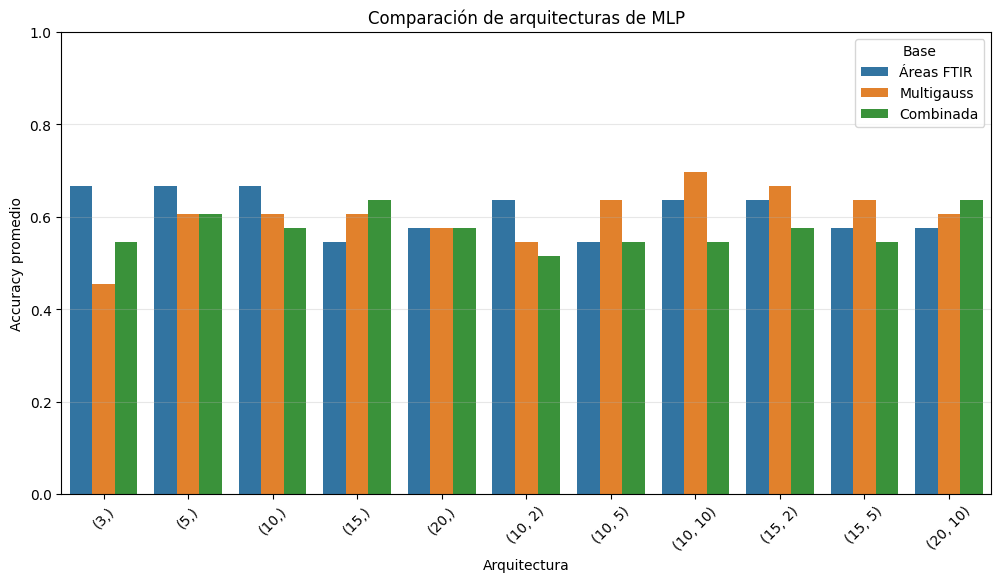

In [77]:
# Graficamos el desempeño de cada arquitectura

# Generamos los resultados explorando las arquitecturas para cada base
resultados_areas_mlp = explorar_arquitecturas(areas, "Áreas FTIR", n_components=2, arquitecturas=arquitecturas, n_splits=3)
resultados_multigauss_mlp = explorar_arquitecturas(multigauss, "Multigauss", n_components=6, arquitecturas=arquitecturas, n_splits=3)
resultados_total_mlp = explorar_arquitecturas(total, "Combinada", n_components=6, arquitecturas=arquitecturas, n_splits=3)

# Concatenamos todos los resultados en un solo DataFrame
resultados_arquitectura = pd.concat(
    [
        resultados_areas_mlp,
        resultados_multigauss_mlp,
        resultados_total_mlp
    ],
    ignore_index=True
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=resultados_arquitectura,
    x="Arquitectura",
    y="Accuracy promedio",
    hue="Base"
)

plt.ylim(0, 1)
plt.xlabel("Arquitectura")
plt.ylabel("Accuracy promedio")
plt.title("Comparación de arquitecturas de MLP")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [78]:
# Seleccionamos la mejor arquitectura para cada base

mejores_arquitecturas = (
    resultados_arquitectura
    .sort_values("Accuracy promedio", ascending=False)
    .groupby("Base")
    .first()
    .reset_index()
)

mejores_arquitecturas.round(4)

,Base,Componentes PCA,Arquitectura,Accuracy promedio,Desviación estándar,Scores por fold
0,Combinada,6,"(20, 10)",0.6364,0.0742,"[0.6363636363636364, 0.5454545454545454, 0.727..."
1,Multigauss,6,"(10, 10)",0.6970,0.1134,"[0.5454545454545454, 0.7272727272727273, 0.818..."
2,Áreas FTIR,2,"(3,)",0.6667,0.0429,"[0.6363636363636364, 0.7272727272727273, 0.636..."


In [80]:
# Mejor resultado global

mejor_global = resultados_arquitectura.sort_values(
    "Accuracy promedio",
    ascending=False
).iloc[0]

mejor_global

,18
Base,Multigauss
Componentes PCA,6
Arquitectura,"(10, 10)"
Accuracy promedio,0.69697
Desviación estándar,0.113384
Scores por fold,"[0.5454545454545454, 0.7272727272727273, 0.818..."


In [82]:
#Ahora probaremos una red neuronal usando TensorFlow
#Esto nos permite comparar una implementacion de red neuronal diferente a sklearn

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [83]:
#Definimos una funcion para construir la red neuronal en TensorFlow
#La arquitectura se puede cambiar indicando el numero de neuronas por capa

def crear_modelo_tf(input_dim, n_clases, arquitectura=(5,), activacion="relu"):

    modelo = Sequential()

    #Primera capa oculta
    modelo.add(
        Dense(
            arquitectura[0],
            activation=activacion,
            input_shape=(input_dim,)
        )
    )

    #Si la arquitectura tiene mas capas, se agregan aqui
    for neuronas in arquitectura[1:]:
        modelo.add(
            Dense(
                neuronas,
                activation=activacion
            )
        )

    #Capa de salida
    #Como tenemos 3 grupos usamos softmax
    modelo.add(
        Dense(
            n_clases,
            activation="softmax"
        )
    )

    modelo.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [84]:
#Funcion para evaluar TensorFlow con validacion cruzada
#En cada fold se escala, se aplica PCA y se entrena la red
#Esto evita que el PCA vea toda la base antes de la validacion

def evaluar_tensorflow(
    df,
    nombre_base,
    n_components,
    arquitectura=(5,),
    activacion="relu",
    n_splits=3,
    epochs=200
):

    X = df.drop(columns=["Muestra", "Grupo"])
    y = encoder.transform(df["Grupo"])

    n_clases = len(np.unique(y))

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=1
    )

    scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        #Escalamos dentro del fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        #Aplicamos PCA dentro del fold
        pca = PCA(n_components=n_components)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)

        #Convertimos las etiquetas a formato categorico
        y_train_cat = to_categorical(y_train, num_classes=n_clases)
        y_test_cat = to_categorical(y_test, num_classes=n_clases)

        #Limpiamos la sesion para que cada fold empiece desde cero
        tf.keras.backend.clear_session()

        modelo = crear_modelo_tf(
            input_dim=n_components,
            n_clases=n_clases,
            arquitectura=arquitectura,
            activacion=activacion
        )

        modelo.fit(
            X_train_pca,
            y_train_cat,
            epochs=epochs,
            verbose=0
        )

        y_pred_prob = modelo.predict(
            X_test_pca,
            verbose=0
        )

        y_pred = np.argmax(y_pred_prob, axis=1)

        acc = accuracy_score(
            y_test,
            y_pred
        )

        scores.append(acc)

        print(f"Fold {fold}: accuracy = {acc:.3f}")

    scores = np.array(scores)

    print(f"\n===== TensorFlow: {nombre_base} =====")
    print("Componentes PCA:", n_components)
    print("Arquitectura:", arquitectura)
    print("Activacion:", activacion)
    print("Accuracy por fold:", scores)
    print("Accuracy promedio:", scores.mean())
    print("Desviacion estandar:", scores.std())

    return scores.mean(), scores.std(), scores

In [85]:
#Evaluamos TensorFlow para las tres bases

acc_tf_areas, std_tf_areas, scores_tf_areas = evaluar_tensorflow(
    areas,
    "Areas FTIR",
    n_components=2,
    arquitectura=(5,),
    activacion="relu",
    n_splits=3,
    epochs=200
)

acc_tf_multigauss, std_tf_multigauss, scores_tf_multigauss = evaluar_tensorflow(
    multigauss,
    "Multigauss",
    n_components=6,
    arquitectura=(5,),
    activacion="relu",
    n_splits=3,
    epochs=200
)

acc_tf_total, std_tf_total, scores_tf_total = evaluar_tensorflow(
    total,
    "Combinada",
    n_components=6,
    arquitectura=(5,),
    activacion="relu",
    n_splits=3,
    epochs=200
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: accuracy = 0.364


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: accuracy = 0.727


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Fold 1: accuracy = 0.455


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: accuracy = 0.273


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3: accuracy = 0.636

===== TensorFlow: Combinada =====
Componentes PCA: 6
Arquitectura: (5,)
Activacion: relu
Accuracy por fold: [0.45454545 0.27272727 0.63636364]
Accuracy promedio: 0.4545454545454546
Desviacion estandar: 0.1484539238050411


In [86]:
#Guardamos los resultados de TensorFlow en una tabla

resultados_tf = pd.DataFrame({
    "Modelo": [
        "TensorFlow",
        "TensorFlow",
        "TensorFlow"
    ],
    "Base": [
        "Areas FTIR",
        "Multigauss",
        "Combinada"
    ],
    "Componentes PCA": [
        2,
        6,
        6
    ],
    "Arquitectura": [
        "(5,)",
        "(5,)",
        "(5,)"
    ],
    "Activacion": [
        "relu",
        "relu",
        "relu"
    ],
    "Accuracy promedio": [
        acc_tf_areas,
        acc_tf_multigauss,
        acc_tf_total
    ],
    "Desviacion estandar": [
        std_tf_areas,
        std_tf_multigauss,
        std_tf_total
    ]
})

resultados_tf.sort_values(
    "Accuracy promedio",
    ascending=False
).round(4)

,Modelo,Base,Componentes PCA,Arquitectura,Activacion,Accuracy promedio,Desviacion estandar
1,TensorFlow,Multigauss,6,"(5,)",relu,0.6970,0.0429
0,TensorFlow,Areas FTIR,2,"(5,)",relu,0.5455,0.1485
2,TensorFlow,Combinada,6,"(5,)",relu,0.4545,0.1485


In [90]:
#Comparamos el mejor resultado de sklearn con TensorFlow
#Como ya no usamos resultados_red, tomamos el mejor resultado desde resultados_arquitecturas

mejor_sklearn = (
    resultados_arquitectura
    .sort_values("Accuracy promedio", ascending=False)
    .iloc[0]
)

mejor_sklearn

,18
Base,Multigauss
Componentes PCA,6
Arquitectura,"(10, 10)"
Accuracy promedio,0.69697
Desviación estándar,0.113384
Scores por fold,"[0.5454545454545454, 0.7272727272727273, 0.818..."


In [91]:
#Convertimos el mejor resultado de sklearn en DataFrame

resultados_sklearn = pd.DataFrame({
    "Modelo": ["MLPClassifier sklearn"],
    "Base": [mejor_sklearn["Base"]],
    "Componentes PCA": [mejor_sklearn["Componentes PCA"]],
    "Arquitectura": [mejor_sklearn["Arquitectura"]],
    "Activacion": ["relu"],
    "Accuracy promedio": [mejor_sklearn["Accuracy promedio"]],
    "Desviacion estandar": [mejor_sklearn["Desviación estándar"]]
})

resultados_sklearn

,Modelo,Base,Componentes PCA,Arquitectura,Activacion,Accuracy promedio,Desviacion estandar
0,MLPClassifier sklearn,Multigauss,6,"(10, 10)",relu,0.69697,0.113384


In [92]:
#Unimos sklearn y TensorFlow en una sola tabla

tabla_comparacion_final = pd.concat(
    [
        resultados_sklearn,
        resultados_tf
    ],
    ignore_index=True
)

tabla_comparacion_final.sort_values(
    "Accuracy promedio",
    ascending=False
).round(4)

,Modelo,Base,Componentes PCA,Arquitectura,Activacion,Accuracy promedio,Desviacion estandar
0,MLPClassifier sklearn,Multigauss,6,"(10, 10)",relu,0.6970,0.1134
2,TensorFlow,Multigauss,6,"(5,)",relu,0.6970,0.0429
1,TensorFlow,Areas FTIR,2,"(5,)",relu,0.5455,0.1485
3,TensorFlow,Combinada,6,"(5,)",relu,0.4545,0.1485


In [94]:
#Convertimos todos los resultados de arquitecturas de sklearn para compararlos con TensorFlow

resultados_sklearn_todos = resultados_arquitectura.copy()

resultados_sklearn_todos["Modelo"] = "MLPClassifier sklearn"
resultados_sklearn_todos["Activacion"] = "relu"

resultados_sklearn_todos = resultados_sklearn_todos[
    [
        "Modelo",
        "Base",
        "Componentes PCA",
        "Arquitectura",
        "Activacion",
        "Accuracy promedio",
        "Desviación estándar"
    ]
]

resultados_sklearn_todos = resultados_sklearn_todos.rename(
    columns={
        "Desviación estándar": "Desviacion estandar"
    }
)

tabla_comparacion_final = pd.concat(
    [
        resultados_sklearn_todos,
        resultados_tf
    ],
    ignore_index=True
)

tabla_comparacion_final.sort_values(
    "Accuracy promedio",
    ascending=False
).round(4)

,Modelo,Base,Componentes PCA,Arquitectura,Activacion,Accuracy promedio,Desviacion estandar
34,TensorFlow,Multigauss,6,"(5,)",relu,0.6970,0.0429
18,MLPClassifier sklearn,Multigauss,6,"(10, 10)",relu,0.6970,0.1134
0,MLPClassifier sklearn,Áreas FTIR,2,"(3,)",relu,0.6667,0.0429
1,MLPClassifier sklearn,Áreas FTIR,2,"(5,)",relu,0.6667,0.0429
19,MLPClassifier sklearn,Multigauss,6,"(15, 2)",relu,0.6667,0.0857
2,MLPClassifier sklearn,Áreas FTIR,2,"(10,)",relu,0.6667,0.0857
25,MLPClassifier sklearn,Combinada,6,"(15,)",relu,0.6364,0.1286
5,MLPClassifier sklearn,Áreas FTIR,2,"(10, 2)",relu,0.6364,0.1286
8,MLPClassifier sklearn,Áreas FTIR,2,"(15, 2)",relu,0.6364,0.0742
17,MLPClassifier sklearn,Multigauss,6,"(10, 5)",relu,0.6364,0.0742


In [95]:
#Seleccionamos el mejor resultado para cada combinación Modelo-Base

tabla_resumen_final = (
    tabla_comparacion_final
    .sort_values("Accuracy promedio", ascending=False)
    .groupby(["Modelo", "Base"])
    .first()
    .reset_index()
)

tabla_resumen_final[
    [
        "Modelo",
        "Base",
        "Componentes PCA",
        "Arquitectura",
        "Activacion",
        "Accuracy promedio",
        "Desviacion estandar"
    ]
].sort_values(
    "Accuracy promedio",
    ascending=False
).round(4)

,Modelo,Base,Componentes PCA,Arquitectura,Activacion,Accuracy promedio,Desviacion estandar
1,MLPClassifier sklearn,Multigauss,6,"(10, 10)",relu,0.6970,0.1134
5,TensorFlow,Multigauss,6,"(5,)",relu,0.6970,0.0429
2,MLPClassifier sklearn,Áreas FTIR,2,"(3,)",relu,0.6667,0.0429
0,MLPClassifier sklearn,Combinada,6,"(15,)",relu,0.6364,0.1286
3,TensorFlow,Areas FTIR,2,"(5,)",relu,0.5455,0.1485
4,TensorFlow,Combinada,6,"(5,)",relu,0.4545,0.1485


In [96]:
mejor_modelo_global = (
    tabla_comparacion_final
    .sort_values("Accuracy promedio", ascending=False)
    .iloc[0]
)

mejor_modelo_global

,34
Modelo,TensorFlow
Base,Multigauss
Componentes PCA,6
Arquitectura,"(5,)"
Activacion,relu
Accuracy promedio,0.69697
Desviacion estandar,0.042855


In [ ]:
#La red muestra una capacidad moderada de clasificación, limitada por el
# tamaño pequeño de la base.Sienso la mejor base para redes Multigauss
#alcanzo el mayor accuracy tanto con sklearn como tensor flow siendo esta
# ulima que con una arquitectura sencilla logro el mismo accuracy qu sklearn
#con una arquitectura mas grande , pero con menor desviacion estandar, eso
#suegiere que este modelo fue el mas estabkle en esta comparacion.